# Visualizzazione dei risultati

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [4]:
with open("/home/anisa_bakiu/Downloads/Progetto_DL_v.2_me/results/metriche_convE.json", "r") as f:
    convE = json.load(f)

with open("/home/anisa_bakiu/Downloads/Progetto_DL_v.2_me/results/metriche_rgcn.json", "r") as f:
    rgcn = json.load(f)

## Metriche principali
Funzione per estrarre le metriche principali in un DataFrame

In [5]:
def extract_metrics(data, model_name):
    records = []
    for category in ["head", "tail", "both"]:
        for scenario in ["optimistic", "realistic", "pessimistic"]:
            metrics = data[category][scenario]
            records.append({
                "Model": model_name,
                "Category": category,
                "Scenario": scenario,
                "Hits@1": metrics["hits_at_1"],
                "Hits@3": metrics["hits_at_3"],
                "Hits@5": metrics["hits_at_5"],
                "Hits@10": metrics["hits_at_10"],
                "Median Rank": metrics["median_rank"],
                "AMR": metrics["arithmetic_mean_rank"],
                "GMR": metrics["geometric_mean_rank"],
                "IHR": metrics["inverse_harmonic_mean_rank"]
            })
    return pd.DataFrame(records)

In [6]:
# Estraggo i DataFrame
df_convE = extract_metrics(convE, "ConvE")
df_rgcn = extract_metrics(rgcn, "R-GCN")

In [ ]:
# Combino i due DataFrame
df = pd.concat([df_convE, df_rgcn], ignore_index=True)
print(df.head())

   Model Category     Scenario    Hits@1    Hits@3    Hits@5   Hits@10  \
0  ConvE     head   optimistic  0.042495  0.073554  0.089929  0.117739   
1  ConvE     head    realistic  0.042495  0.073554  0.089929  0.117739   
2  ConvE     head  pessimistic  0.042495  0.073554  0.089929  0.117739   
3  ConvE     tail   optimistic  0.208447  0.266797  0.289539  0.318129   
4  ConvE     tail    realistic  0.208447  0.266797  0.289539  0.318129   

   Median Rank          AMR         GMR       IHR  
0        612.0  6424.820793  487.170520  0.072225  
1        612.0  6424.820801  487.170593  0.072225  
2        612.0  6424.821442  487.170571  0.072225  
3        506.0  8233.463548  266.184641  0.247770  
4        506.0  8233.462891  266.184692  0.247770  


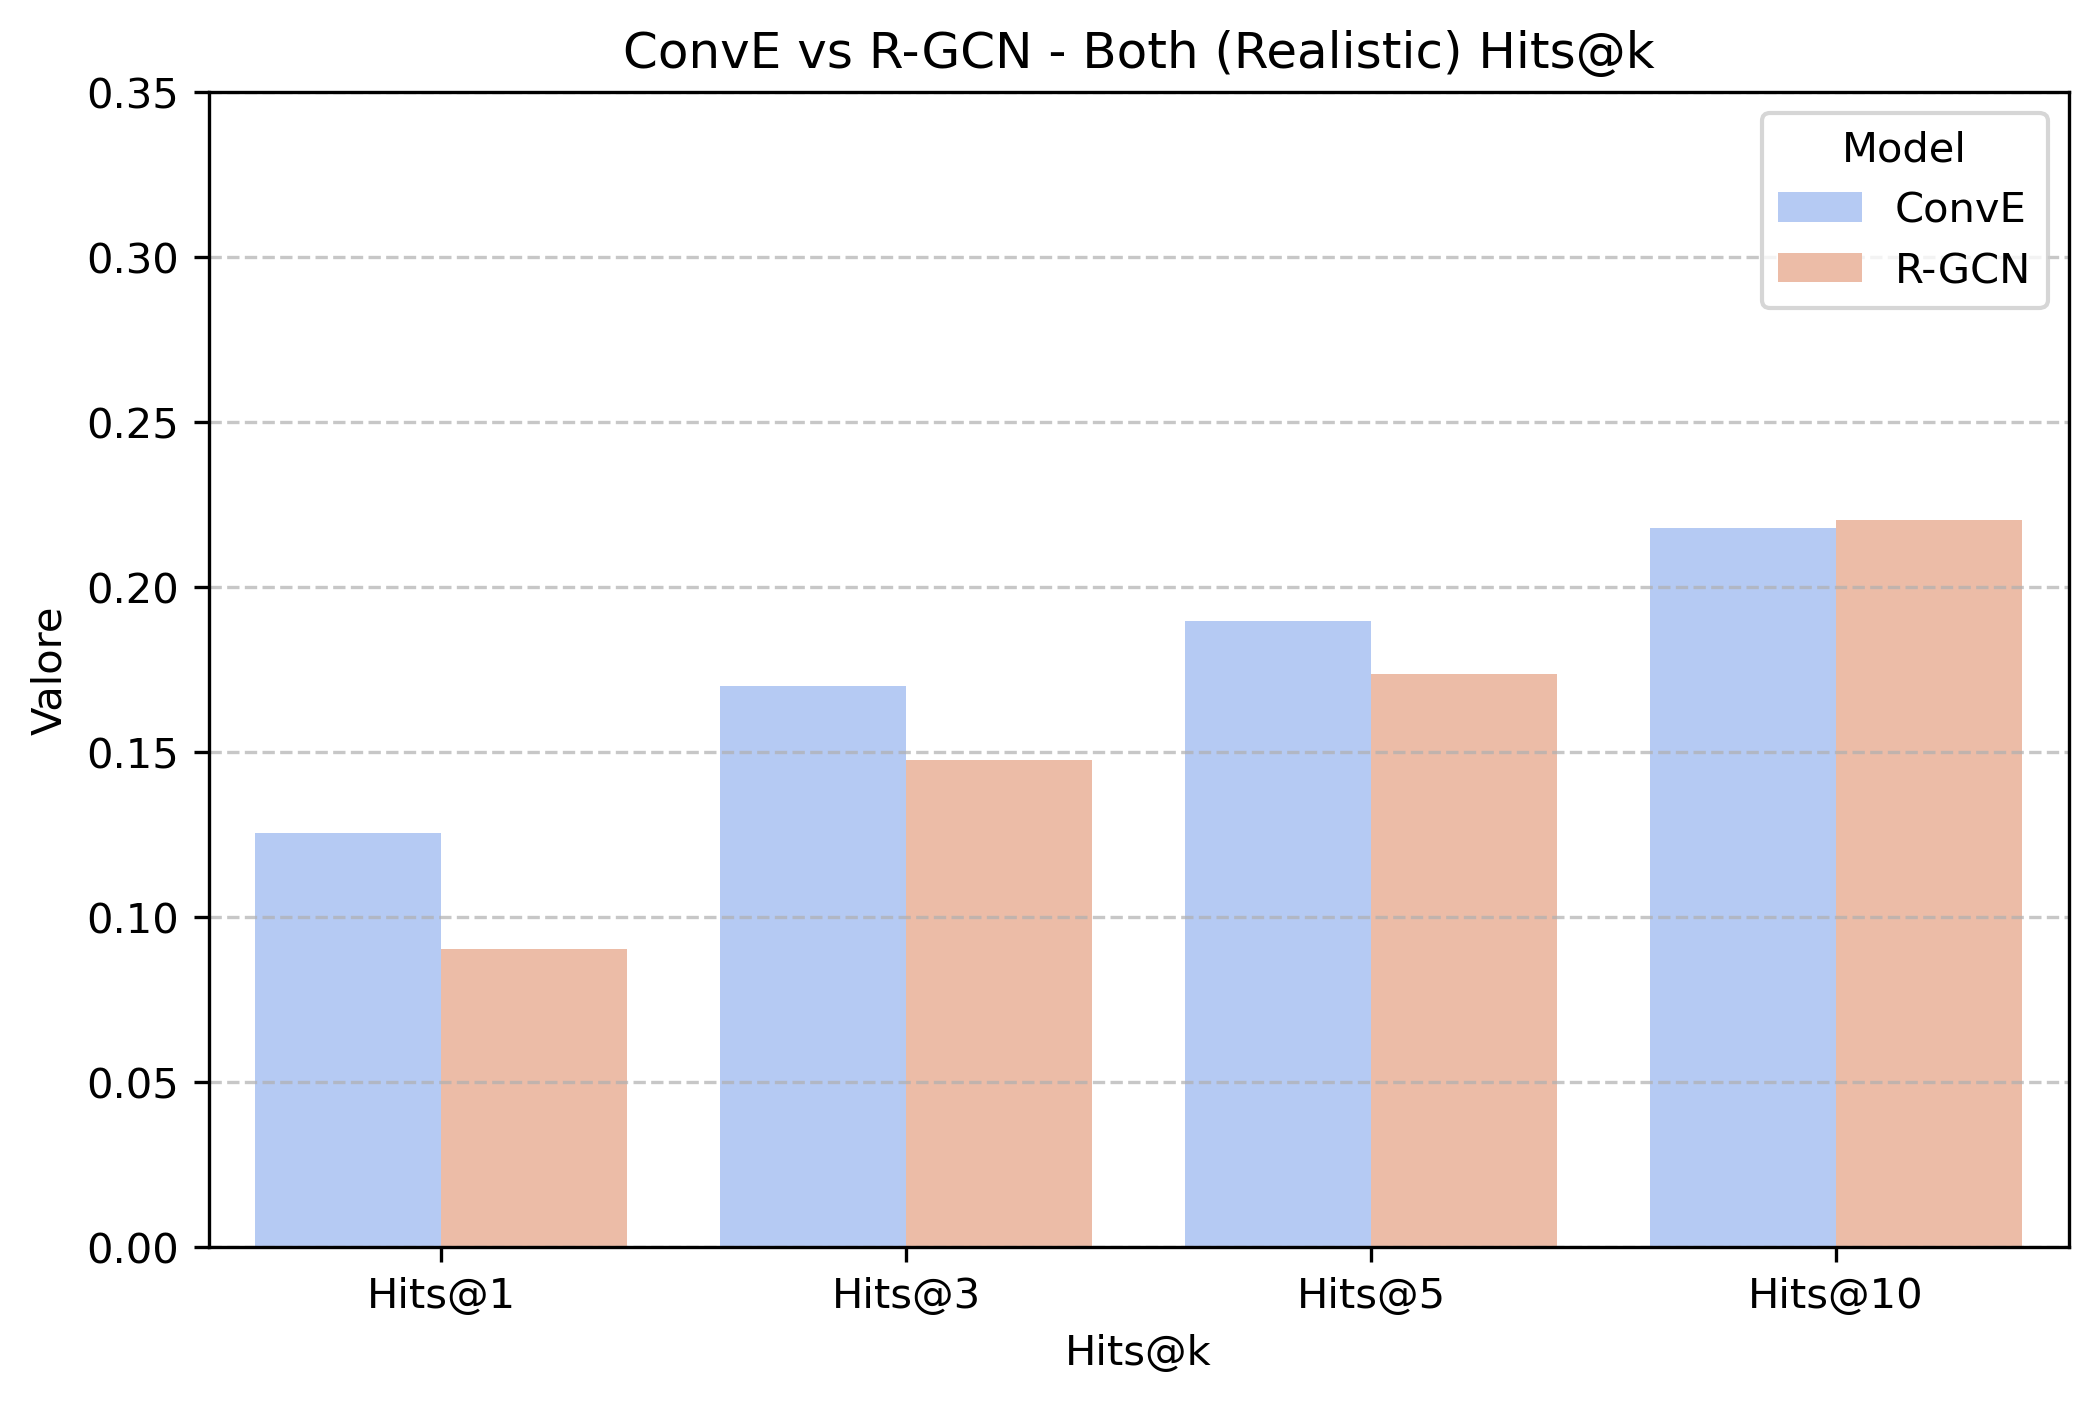

In [8]:
df_melt = df.melt(id_vars=["Model", "Category", "Scenario"], 
                  value_vars=["Hits@1", "Hits@3", "Hits@5", "Hits@10"], 
                  var_name="Hits@k", value_name="Valore")

df_plot = df_melt[(df_melt["Category"]=="both") & (df_melt["Scenario"]=="realistic")]

plt.figure(figsize=(8,5), dpi = 300)
sns.barplot(x="Hits@k", y="Valore", hue="Model", data=df_plot, palette="coolwarm")
plt.title("ConvE vs R-GCN - Both (Realistic) Hits@k")
plt.ylim(0, 0.35)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

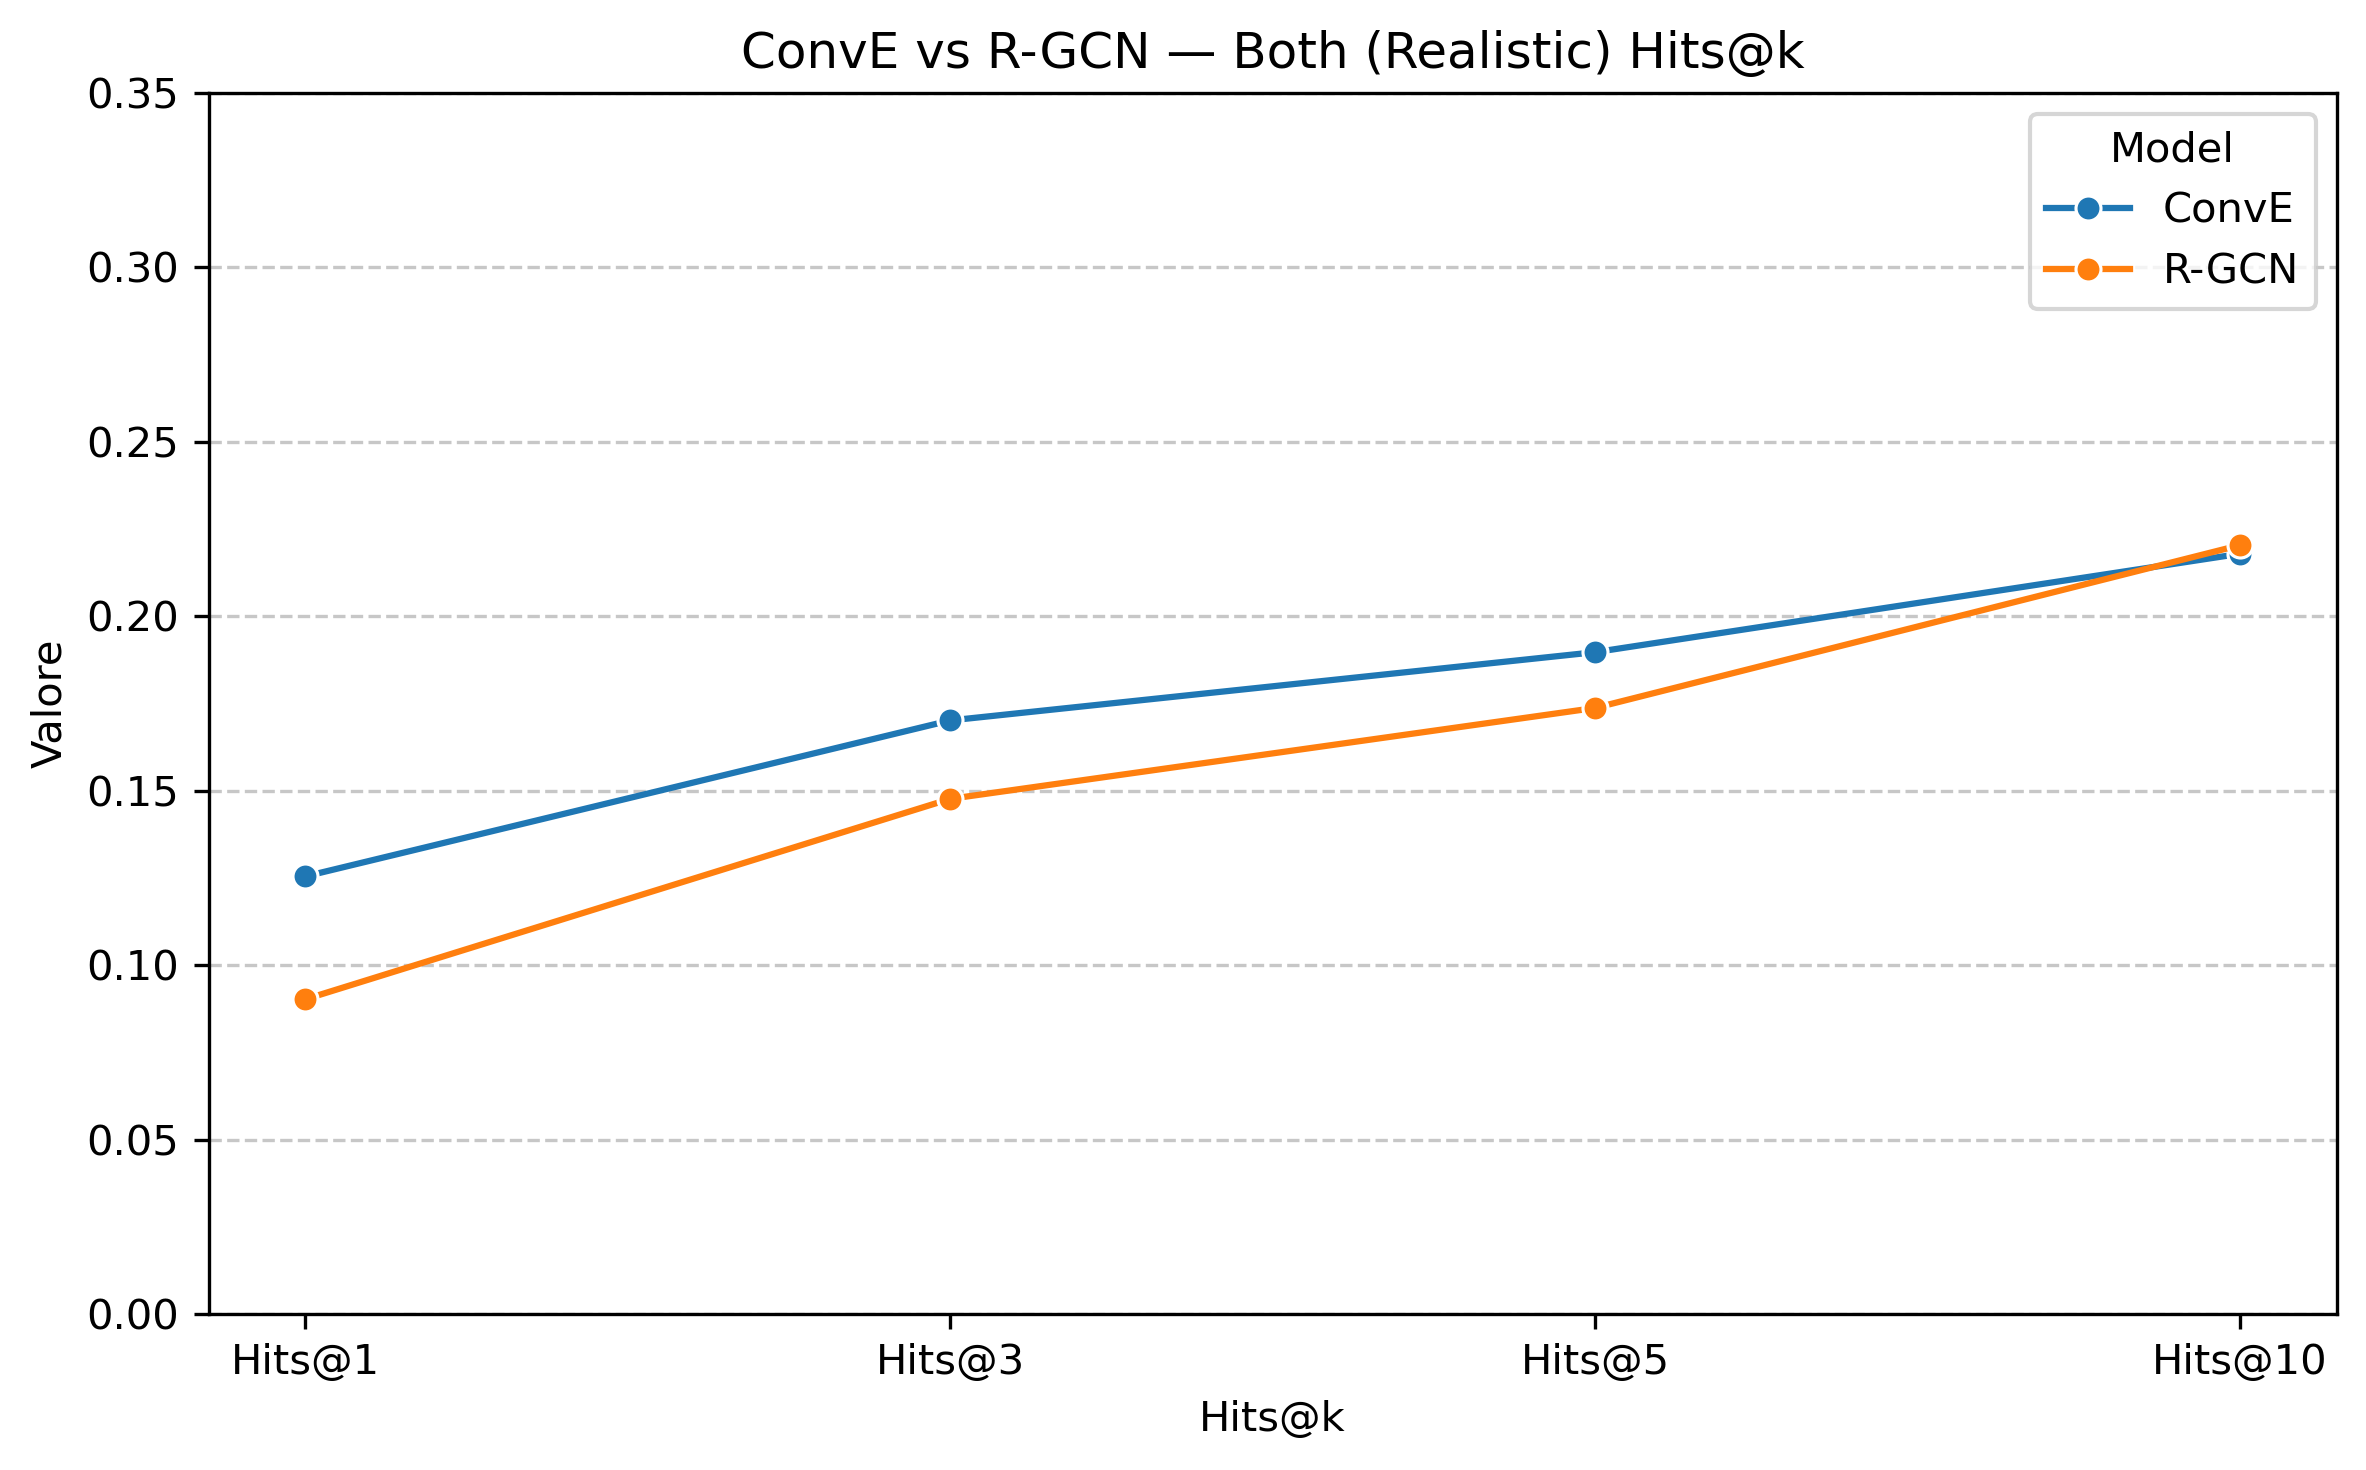

In [12]:
plt.figure(figsize=(8,5), dpi=300)

sns.lineplot(
    data=df_plot,
    x="Hits@k",
    y="Valore",
    hue="Model",
    marker="o"
)

plt.title("ConvE vs R-GCN — Both (Realistic) Hits@k")
plt.ylim(0, 0.35)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
df_br = df[(df["Category"] == "both") & (df["Scenario"] == "realistic")]
df_br

,Model,Category,Scenario,Hits@1,Hits@3,Hits@5,Hits@10,Median Rank,AMR,GMR,IHR
7,ConvE,both,realistic,0.125471,0.170175,0.189734,0.217934,563.0,7329.142578,360.107513,0.159997
16,R-GCN,both,realistic,0.090253,0.147693,0.173749,0.220403,133.0,2727.367676,155.451202,0.136678


In [ ]:
df_br.to_latex(
    index=True,                         
    caption="Metriche della performance",
    label="tab:metriche_modelli",       
    float_format="%.3f",               
    longtable=True,                      
    column_format="l" + "c" * (len(df_br.columns))
)

'\\begin{longtable}{lccccccccccc}\n\\caption{Metriche della performance} \\label{tab:metriche_modelli} \\\\\n\\toprule\n & Model & Category & Scenario & Hits@1 & Hits@3 & Hits@5 & Hits@10 & Median Rank & AMR & GMR & IHR \\\\\n\\midrule\n\\endfirsthead\n\\caption[]{Metriche della performance} \\\\\n\\toprule\n & Model & Category & Scenario & Hits@1 & Hits@3 & Hits@5 & Hits@10 & Median Rank & AMR & GMR & IHR \\\\\n\\midrule\n\\endhead\n\\midrule\n\\multicolumn{12}{r}{Continued on next page} \\\\\n\\midrule\n\\endfoot\n\\bottomrule\n\\endlastfoot\n7 & ConvE & both & realistic & 0.125 & 0.170 & 0.190 & 0.218 & 563.000 & 7329.143 & 360.108 & 0.160 \\\\\n16 & R-GCN & both & realistic & 0.090 & 0.148 & 0.174 & 0.220 & 133.000 & 2727.368 & 155.451 & 0.137 \\\\\n\\end{longtable}\n'